# Probability Distributions and Simulation

A compact Python-first introduction to probability functions, random generation, and Monte Carlo verification of theoretical results.

## 1. Core functions

For a discrete random variable, the **probability mass function (PMF)** gives $P(X=x)$. For a continuous random variable, the **probability density function (PDF)** describes density; probabilities are areas, so $P(X=x)=0$.

The **cumulative distribution function (CDF)** is
$$F(x)=P(X\leq x).$$
A quantile $q_p$ satisfies $F(q_p)=p$ (more generally, $q_p=\inf\{x:F(x)\geq p\}$).

In `scipy.stats`, the common interface is:

- `pdf` or `pmf`: density or probability mass
- `cdf`: cumulative probability
- `ppf`: quantile function (inverse CDF)
- `rvs`: random generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

SEED = 42
rng = np.random.default_rng(SEED)

## 2. Continuous distributions

We examine four common continuous models. SciPy uses `scale = 1 / rate` for exponential and gamma distributions.

| Distribution | Parameters used here | Mean | Variance |
|---|---:|---:|---:|
| Normal | $\mu,\sigma$ | $\mu$ | $\sigma^2$ |
| Uniform | $a,b$ | $(a+b)/2$ | $(b-a)^2/12$ |
| Exponential (rate) | $\lambda$ | $1/\lambda$ | $1/\lambda^2$ |
| Gamma (shape-rate) | $\alpha,\beta$ | $\alpha/\beta$ | $\alpha/\beta^2$ |

In [2]:
continuous = {
    "Normal(0, 1)": stats.norm(loc=0, scale=1),
    "Uniform(0, 1)": stats.uniform(loc=0, scale=1),
    "Exponential(rate=2)": stats.expon(scale=1 / 2),
    "Gamma(shape=3, rate=2)": stats.gamma(a=3, scale=1 / 2),
}

summary = []
for name, distribution in continuous.items():
    mean, variance = distribution.stats(moments="mv")
    summary.append({
        "distribution": name,
        "theoretical_mean": float(mean),
        "theoretical_variance": float(variance),
        "median_q50": float(distribution.ppf(0.50)),
        "q95": float(distribution.ppf(0.95)),
    })

pd.DataFrame(summary).set_index("distribution").round(4)

,theoretical_mean,theoretical_variance,median_q50,q95
distribution,,,,
"Normal(0, 1)",0.0,1.0000,0.0000,1.6449
"Uniform(0, 1)",0.5,0.0833,0.5000,0.9500
Exponential(rate=2),0.5,0.2500,0.3466,1.4979
"Gamma(shape=3, rate=2)",1.5,0.7500,1.3370,3.1479


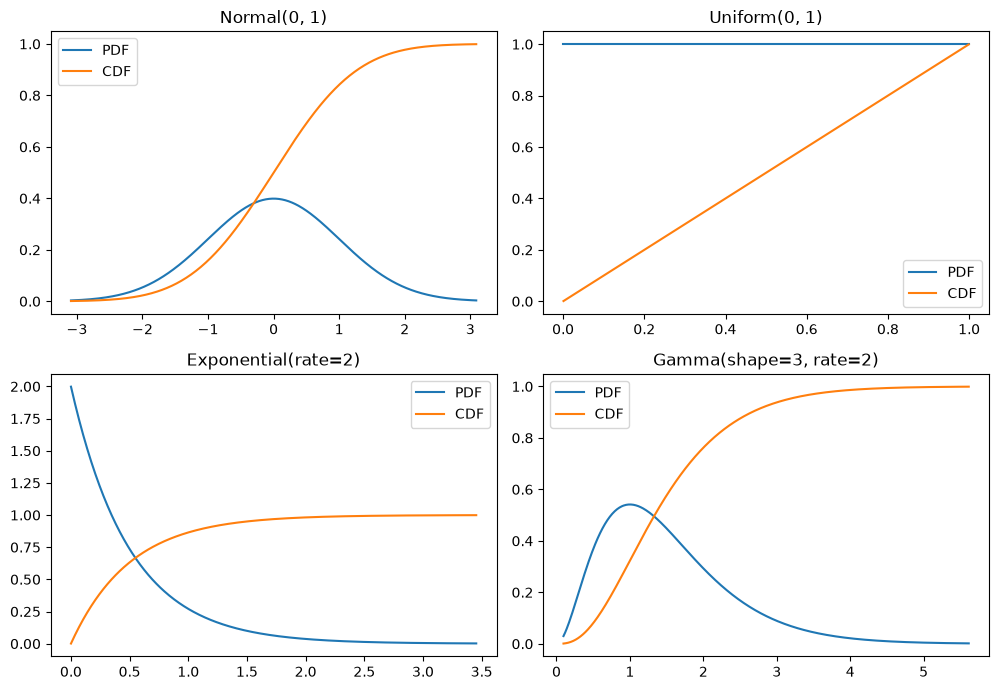

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, (name, distribution) in zip(axes.flat, continuous.items()):
    lower, upper = distribution.ppf([0.001, 0.999])
    x = np.linspace(lower, upper, 500)
    ax.plot(x, distribution.pdf(x), label="PDF")
    ax.plot(x, distribution.cdf(x), label="CDF")
    ax.set_title(name)
    ax.legend()
fig.tight_layout()
plt.show()

## 3. Discrete distributions

| Distribution | Parameters used here | Mean | Variance |
|---|---:|---:|---:|
| Binomial | $n,p$ | $np$ | $np(1-p)$ |
| Poisson | $\lambda$ | $\lambda$ | $\lambda$ |

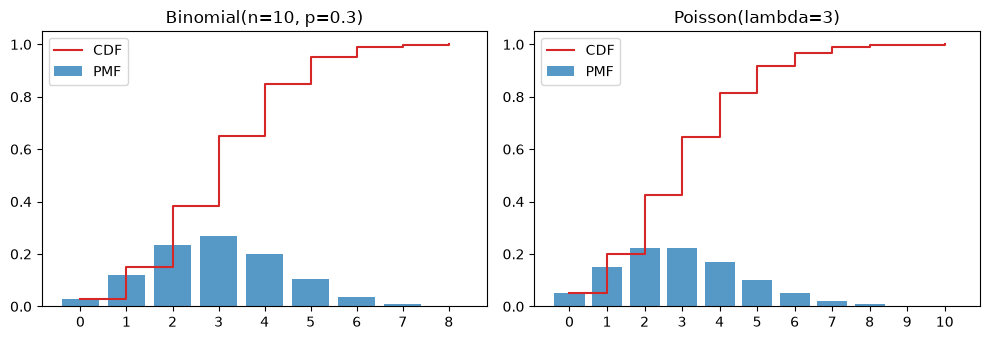

In [4]:
discrete = {
    "Binomial(n=10, p=0.3)": stats.binom(n=10, p=0.3),
    "Poisson(lambda=3)": stats.poisson(mu=3),
}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, (name, distribution) in zip(axes, discrete.items()):
    upper = int(distribution.ppf(0.999))
    x = np.arange(0, upper + 1)
    ax.bar(x, distribution.pmf(x), alpha=0.75, label="PMF")
    ax.step(x, distribution.cdf(x), where="post", color="tab:red", label="CDF")
    ax.set_title(name)
    ax.set_xticks(x)
    ax.legend()
fig.tight_layout()
plt.show()

## 4. Random generation: empirical vs theoretical moments

The law of large numbers suggests that empirical moments approach their theoretical counterparts as the simulation size grows. Differences remain because Monte Carlo estimates contain sampling error.

In [5]:
all_distributions = {**continuous, **discrete}
simulation_size = 100_000
rows = []

for name, distribution in all_distributions.items():
    sample = distribution.rvs(size=simulation_size, random_state=rng)
    theoretical_mean, theoretical_variance = distribution.stats(moments="mv")
    rows.append({
        "distribution": name,
        "theoretical_mean": float(theoretical_mean),
        "empirical_mean": sample.mean(),
        "theoretical_variance": float(theoretical_variance),
        "empirical_variance": sample.var(ddof=1),
    })

moment_comparison = pd.DataFrame(rows).set_index("distribution")
moment_comparison.round(4)

,theoretical_mean,empirical_mean,theoretical_variance,empirical_variance
distribution,,,,
"Normal(0, 1)",0.0,-0.0042,1.0000,1.0074
"Uniform(0, 1)",0.5,0.4990,0.0833,0.0834
Exponential(rate=2),0.5,0.4994,0.2500,0.2506
"Gamma(shape=3, rate=2)",1.5,1.4998,0.7500,0.7454
"Binomial(n=10, p=0.3)",3.0,3.0041,2.1000,2.0884
Poisson(lambda=3),3.0,3.0054,3.0000,3.0022


## 5. Monte Carlo example: estimating a probability

For $X\sim N(0,1)$, estimate $P(-1\leq X\leq1)$ and compare it with the exact CDF calculation. A Monte Carlo standard error for an estimated probability $\widehat p$ based on $M$ simulations is
$$\operatorname{MCSE}(\widehat p)\approx\sqrt{\widehat p(1-\widehat p)/M}.$$

In [6]:
M = 100_000
z = rng.normal(size=M)
p_hat = np.mean((z >= -1) & (z <= 1))
p_exact = stats.norm.cdf(1) - stats.norm.cdf(-1)
mcse = np.sqrt(p_hat * (1 - p_hat) / M)

pd.Series({"Monte Carlo estimate": p_hat, "Exact probability": p_exact, "MC standard error": mcse})

Monte Carlo estimate    0.682650
Exact probability       0.682689
MC standard error       0.001472
dtype: float64

## 6. Monte Carlo example: expectation by simulation

If $X\sim\operatorname{Exp}(\lambda=2)$, estimate $E[e^{-X}]$. For an exponential rate $\lambda$, the theoretical value is $\lambda/(\lambda+1)=2/3$.

In [7]:
M = 100_000
x = rng.exponential(scale=1 / 2, size=M)
values = np.exp(-x)
estimate = values.mean()
mcse = values.std(ddof=1) / np.sqrt(M)

pd.Series({"Monte Carlo estimate": estimate, "Theoretical value": 2 / 3, "MC standard error": mcse})

Monte Carlo estimate    0.667529
Theoretical value       0.666667
MC standard error       0.000742
dtype: float64

## 7. Takeaways

- Use PMFs for discrete variables and PDFs for continuous variables.
- The CDF handles both types and directly represents cumulative probabilities.
- Quantiles invert cumulative probabilities.
- Always document parameterization, especially `rate` versus `scale`.
- Reproducible random generation requires an explicit seed or generator.
- A Monte Carlo result should be reported with its simulation size and Monte Carlo uncertainty.